<a href="https://colab.research.google.com/github/Thalyanalves/Engenharia_de_prompt_e_aplicacao_AI/blob/main/Aula08_Colabora%C3%A7%C3%A3oComIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula do dia 13/04, conteúdo automação e exercícios práticos com o gemini
(Leitura de script, ghostwiter e tratamento de erros)
Nome: Thalyana Mendes
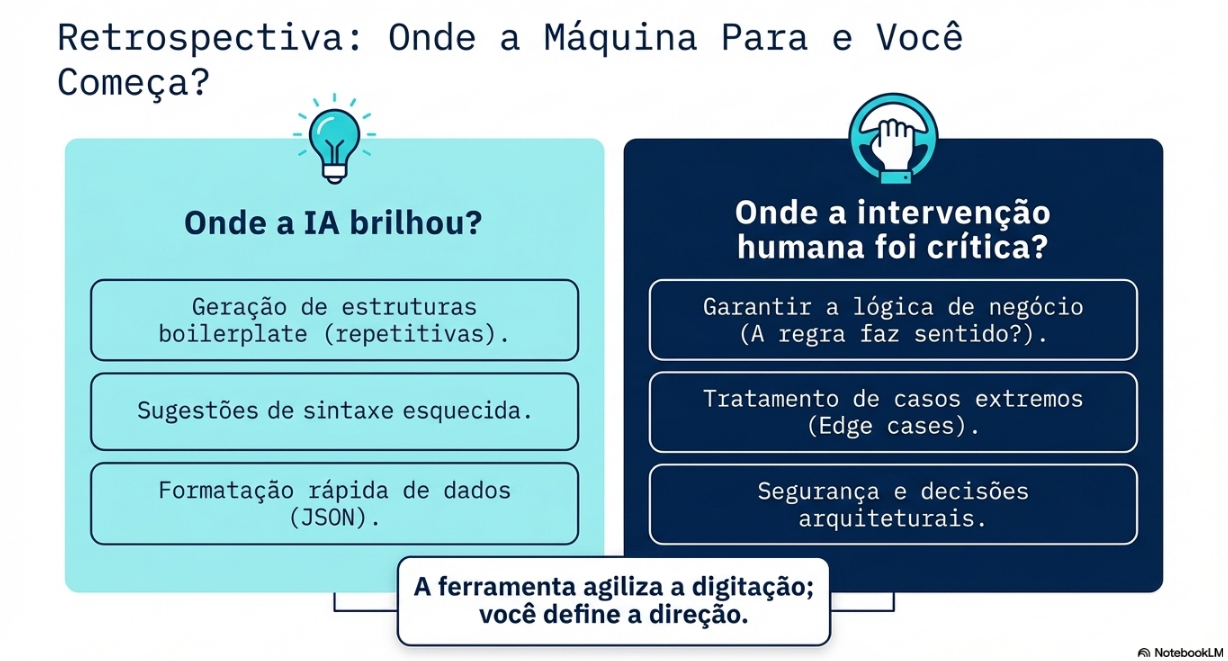


In [2]:
'''
Dissecando um script
crie um script python para verificar a temperatura de um sistema.
Se for maior que 30, exiba um alerta de super aquecimento.
'''

def check_temperature():
    try:
        temperature = float(input("Por favor, insira a temperatura do sistema em Celsius: "))
        if temperature > 30:
            print("ALERTA: Superaquecimento! A temperatura do sistema está acima de 30°C.")
        else:
            print("A temperatura do sistema é " + str(temperature) + "°C. Tudo parece normal.")
    except ValueError:
        print("Entrada inválida. Por favor, insira um número para a temperatura.")

check_temperature()

Por favor, insira a temperatura do sistema em Celsius: 10
A temperatura do sistema é 10.0°C. Tudo parece normal.


In [ ]:
from IPython.core.magics import script
'''desenvolver um script que consulte uma api pública Viacep e retorne as informações de endereço formatada de maneira legível
requisitos: integração com a api viacep, json rebido e formatado com clareza, erros de conexão ou cep inválido, são tratados sem quebrar o script'''

In [4]:
import requests

def consultar_cep(cep):
    url = f"https://viacep.com.br/ws/{cep}/json/"
    try:
        response = requests.get(url)
        response.raise_for_status() # Lança exceção para códigos de status HTTP de erro (4xx ou 5xx)
        data = response.json()

        if "erro" in data and data["erro"]:
            print(f"CEP inválido: {cep}. Por favor, verifique o número inserido.")
        else:
            print("--- Informações do Endereço ---")
            print(f"CEP: {data.get('cep', 'Não informado')}")
            print(f"Logradouro: {data.get('logradouro', 'Não informado')}")
            print(f"Complemento: {data.get('complemento', 'Não informado')}")
            print(f"Bairro: {data.get('bairro', 'Não informado')}")
            print(f"Localidade: {data.get('localidade', 'Não informado')}")
            print(f"UF: {data.get('uf', 'Não informado')}")
            print(f"IBGE: {data.get('ibge', 'Não informado')}")
            print(f"DDD: {data.get('ddd', 'Não informado')}")
            print("-------------------------------")

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP ao consultar o CEP {cep}: {http_err}")
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de conexão ao consultar o CEP {cep}: {conn_err}. Verifique sua conexão com a internet.")
    except requests.exceptions.Timeout as timeout_err:
        print(f"Tempo limite excedido ao consultar o CEP {cep}: {timeout_err}. O servidor demorou muito para responder.")
    except requests.exceptions.RequestException as req_err:
        print(f"Erro inesperado ao consultar o CEP {cep}: {req_err}")
    except ValueError:
        print("Erro ao decodificar JSON. A resposta da API pode não ser um JSON válido.")

# Exemplo de uso:
# Para testar, descomente e execute a linha abaixo, ou chame a função com um CEP desejado.
cep_digitado = input("Por favor, digite o CEP a ser consultado (apenas números): ")
if cep_digitado.isdigit() and len(cep_digitado) == 8:
    consultar_cep(cep_digitado)
else:
    print("Formato de CEP inválido. Por favor, insira um CEP de 8 dígitos numéricos.")

Por favor, digite o CEP a ser consultado (apenas números): 70297400
--- Informações do Endereço ---
CEP: 70297-400
Logradouro: Quadra EQS 414/415
Complemento: 
Bairro: Asa Sul
Localidade: Brasília
UF: DF
IBGE: 5300108
DDD: 61
-------------------------------
